In [1]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from nbt import nbt
import base64
import gzip
import io
import re
from tqdm import tqdm
from collections import defaultdict
import xgboost as xgb
from sklearn.model_selection import train_test_split
import xgboost as xgb
import re
from sklearn.metrics import mean_absolute_error, r2_score
import json
import gc
import numba
from sklearn.preprocessing import LabelEncoder

# Load the mysql database into memory

In [2]:
# 1. Manually find the .env file relative to this notebook
# '..' goes up to src, the second '..' goes up to the root
env_path = Path('../../.env')
load_dotenv(dotenv_path=env_path)

# 2. Now os.getenv will work
USER = os.getenv("MYSQL_USER")
PASSWORD = os.getenv("MYSQL_PASSWORD")
DATABASE = os.getenv("MYSQL_DATABASE")
HOST = "localhost"
HOST = "192.168.86.4"
PORT = "3306"

# 3. Create the engine and load
engine = create_engine(f"mysql+mysqlconnector://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}")

df = pd.read_sql("SELECT * FROM auctions", engine)
print(df)

print(f"Success! Loaded {len(df)} rows.")

                            auction_uuid                       seller_uuid  \
0       00001b5924f7416cbfc07aea2bc1fe97  a2c1748fc4924d13a9a7f485bbddf2b2   
1       00007a777db64d88ba510f8a36a7fc86  c180cd6ee2d54867939a222330873214   
2       000080f21c2e4c389b57e1ad1acf431a  22e08a67e5b045ef8f6c2fedd16563f7   
3       0000a8f6110a47cfa630792ab3cf6328  930ab244d65747aaac0b0481ce743845   
4       0000a9452010475c8eeb48cfcd1088cc  2866ef326f4f47d59b85eda1c501971d   
...                                  ...                               ...   
471035  ffff98178c064a839a7080a9a6d88d89  2e0957c542ba4ae6adeff8de604b5845   
471036  ffffb3be64234313a3655b5734ccd339  21fcfb8104ab4016b4d2fb21a2314b30   
471037  ffffbbc0a1e84c849770800cbbec0aff  1cea59fb65ff4872a24604b493fe3139   
471038  ffffc6391f01414fa8f62cad81e6735a  78664fe51b8041b1aea0c27617f357f4   
471039  ffffe955ec3b4c6f8cd99a119943f7df  ba0809572308456e864a489796fde87a   

                              buyer_uuid  final_price  bin  \
0

In [3]:
def print_all_tags(tag, indent=0):
    """
    Recursively prints all NBT tags and their values.
    """
    prefix = "  " * indent
    
    # If it's a Compound tag (like a folder/dictionary)
    if isinstance(tag, nbt.TAG_Compound):
        for key, value in tag.items():
            print(f"{prefix}{key}:")
            print_all_tags(value, indent + 1)
            
    # If it's a List tag
    elif isinstance(tag, nbt.TAG_List):
        print(f"{prefix}[List of {len(tag)} items]")
        for i, item in enumerate(tag):
            print(f"{prefix}  Index {i}:")
            print_all_tags(item, indent + 2)
            
    # If it's a standard Value tag (String, Int, Byte, etc.)
    else:
        # Clean formatting codes if the value is a string
        val = tag.value
        if isinstance(val, str):
            val = re.sub(r'(§[0-9a-fk-or])', '', val)
        print(f"{prefix}{val}")


def decode_nbt(raw_base64):
    try:
        # 1. Decode Base64
        decoded_data = base64.b64decode(raw_base64)
        
        # 2. Decompress GZip
        uncompressed_data = gzip.decompress(decoded_data)
        
        # 3. Parse NBT
        buffer = io.BytesIO(uncompressed_data)
        nbt_data = nbt.NBTFile(buffer=buffer)
        
        # 4. Navigate to the first item in the list
        # Skyblock/Minecraft auction data usually wraps items in an 'i' list
        items_list = nbt_data["i"]
        return items_list
            
    except Exception as e:
        #print(f"Failed to decode NBT: {e}")
        pass

def decode_and_print_all(raw_base64):
    try:
        items_list = decode_nbt(raw_base64)
        
        for index, item in enumerate(items_list):
            print(f"--- Item #{index} ---")
            print_all_tags(item)
            print("-" * 20)
            
    except Exception as e:
        print(f"Failed to decode NBT: {e}")

## Processing

In [4]:
# Get the raw counts
bin_counts = df['bin'].value_counts()

print("Distribution of Auction Types:")
print(f"BIN (1): {bin_counts.get(1, 0)}")
print(f"Auction (0): {bin_counts.get(0, 0)}")

# Pro-tip: For ML, you often want the percentage/proportion
print("\nProportions:")
print(df['bin'].value_counts(normalize=True))

Distribution of Auction Types:
BIN (1): 463002
Auction (0): 8038

Proportions:
bin
1    0.982936
0    0.017064
Name: proportion, dtype: float64


Seeing as how under 2% of collected auctions were not BIN (Buy It Now), but regular bidding auctions, I have decided to remove these from the training data because in regular auctions, bidding wars occur, where people bid with emotion, not logic, and tend to overpay.


In [5]:
df = df[df['bin'] == 1]
print(df)

                            auction_uuid                       seller_uuid  \
0       00001b5924f7416cbfc07aea2bc1fe97  a2c1748fc4924d13a9a7f485bbddf2b2   
1       00007a777db64d88ba510f8a36a7fc86  c180cd6ee2d54867939a222330873214   
2       000080f21c2e4c389b57e1ad1acf431a  22e08a67e5b045ef8f6c2fedd16563f7   
3       0000a8f6110a47cfa630792ab3cf6328  930ab244d65747aaac0b0481ce743845   
4       0000a9452010475c8eeb48cfcd1088cc  2866ef326f4f47d59b85eda1c501971d   
...                                  ...                               ...   
471034  ffff35895c8e4f2d9557fcfd796c0862  1d8badf4062c437a895a4b83c1a4d4fe   
471035  ffff98178c064a839a7080a9a6d88d89  2e0957c542ba4ae6adeff8de604b5845   
471036  ffffb3be64234313a3655b5734ccd339  21fcfb8104ab4016b4d2fb21a2314b30   
471037  ffffbbc0a1e84c849770800cbbec0aff  1cea59fb65ff4872a24604b493fe3139   
471039  ffffe955ec3b4c6f8cd99a119943f7df  ba0809572308456e864a489796fde87a   

                              buyer_uuid  final_price  bin  \
0

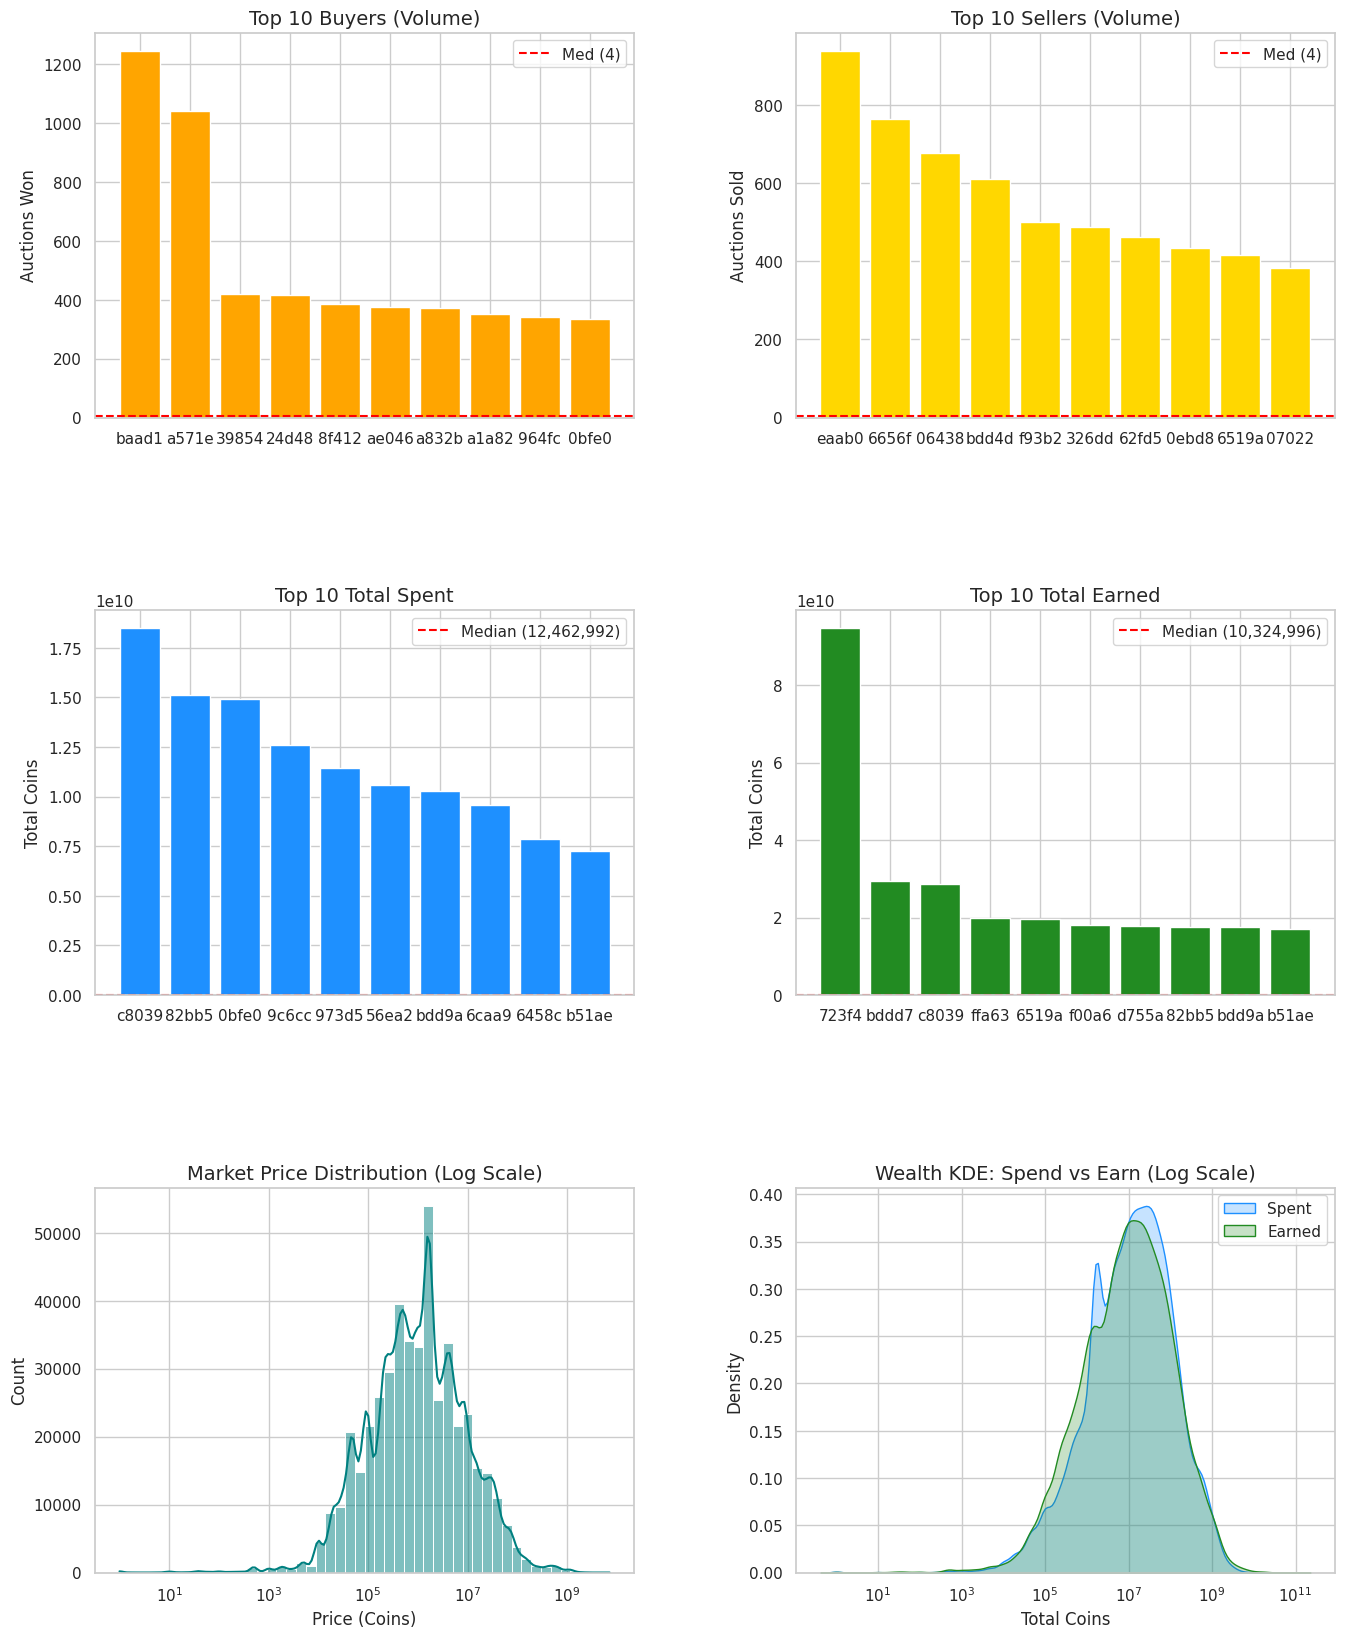

In [6]:
# --- 1. Setup Style & Canvas ---
sns.set_theme(style="whitegrid")
# Using a 3x2 grid to fit all 6 visualizations
fig, axes = plt.subplots(3, 2, figsize=(16, 20))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

# --- ROW 1: VOLUME (TRANSACTION COUNTS) ---

# 1. Top 10 Buyers (Last 5 Chars)
buyer_counts = df['buyer_uuid'].value_counts().head(10)
short_buyer_ids = [str(x)[-5:] for x in buyer_counts.index]
axes[0, 0].bar(short_buyer_ids, buyer_counts.values, color='orange')
median_purchases = df['buyer_uuid'].value_counts().median()
axes[0, 0].axhline(y=median_purchases, color='red', linestyle='--', label=f'Med ({median_purchases:,.0f})')
axes[0, 0].set_title('Top 10 Buyers (Volume)', fontsize=14)
axes[0, 0].set_ylabel('Auctions Won')
axes[0, 0].legend()

# 2. Top 10 Sellers (Last 5 Chars)
seller_counts = df['seller_uuid'].value_counts().head(10)
short_seller_ids = [str(x)[-5:] for x in seller_counts.index]
axes[0, 1].bar(short_seller_ids, seller_counts.values, color='gold')
median_sales = df['seller_uuid'].value_counts().median()
axes[0, 1].axhline(y=median_sales, color='red', linestyle='--', label=f'Med ({median_sales:,.0f})')
axes[0, 1].set_title('Top 10 Sellers (Volume)', fontsize=14)
axes[0, 1].set_ylabel('Auctions Sold')
axes[0, 1].legend()

# --- ROW 2: VALUE (COIN FLOW) ---

# 3. Top 10 Spenders (Last 5 Chars)
spent_per_player = df.groupby('buyer_uuid')['final_price'].sum().sort_values(ascending=False).head(10)
short_spender_ids = [str(x)[-5:] for x in spent_per_player.index]
axes[1, 0].bar(short_spender_ids, spent_per_player.values, color='dodgerblue')
median_spent = df.groupby('buyer_uuid')['final_price'].sum().median()
# Added value to median in legend
axes[1, 0].axhline(y=median_spent, color='red', linestyle='--', label=f'Median ({median_spent:,.0f})')
axes[1, 0].set_title('Top 10 Total Spent', fontsize=14)
axes[1, 0].set_ylabel('Total Coins')
axes[1, 0].legend()

# 4. Top 10 Earners (Last 5 Chars)
earned_per_player = df.groupby('seller_uuid')['final_price'].sum().sort_values(ascending=False).head(10)
short_earner_ids = [str(x)[-5:] for x in earned_per_player.index]
axes[1, 1].bar(short_earner_ids, earned_per_player.values, color='forestgreen')
median_earned = df.groupby('seller_uuid')['final_price'].sum().median()
# Added value to median in legend
axes[1, 1].axhline(y=median_earned, color='red', linestyle='--', label=f'Median ({median_earned:,.0f})')
axes[1, 1].set_title('Top 10 Total Earned', fontsize=14)
axes[1, 1].set_ylabel('Total Coins')
axes[1, 1].legend()

# --- ROW 3: GLOBAL DISTRIBUTIONS ---

# 5. Price Distribution (Log Scale)
sns.histplot(df['final_price'], bins=50, kde=True, ax=axes[2, 0], log_scale=True, color='teal')
axes[2, 0].set_title('Market Price Distribution (Log Scale)', fontsize=14)
axes[2, 0].set_xlabel('Price (Coins)')

# 6. Money Spent vs Earned Distribution
full_spent = df.groupby('buyer_uuid')['final_price'].sum()
full_earned = df.groupby('seller_uuid')['final_price'].sum()
sns.kdeplot(full_spent, ax=axes[2, 1], log_scale=True, label='Spent', fill=True, color='dodgerblue')
sns.kdeplot(full_earned, ax=axes[2, 1], log_scale=True, label='Earned', fill=True, color='forestgreen')
axes[2, 1].set_title('Wealth KDE: Spend vs Earn (Log Scale)', fontsize=14)
axes[2, 1].set_xlabel('Total Coins')
axes[2, 1].legend()

plt.show()

In [7]:
sample_row = df.sample(1).iloc[0]

# 2. Pass the specific string to the function
# (No KeyError because sample_row is a Series where 'item_bytes' is a valid key)
decoded_nbt = decode_nbt(sample_row['item_bytes'])

for item in decoded_nbt:
    print(item)

print(decode_and_print_all(sample_row['item_bytes']))

{TAG_Short('id'): 397, TAG_Byte('Count'): 1, TAG_Compound('tag'): {4 Entries}, TAG_Short('Damage'): 3}
--- Item #0 ---
id:
  397
Count:
  1
tag:
  HideFlags:
    254
  SkullOwner:
    Id:
      98100c2f-9bc9-3390-b086-46dc50101472
    hypixelPopulated:
      1
    Properties:
      textures:
        [List of 1 items]
          Index 0:
            Signature:
              EU6oB9ZysxgBRUf09TLH/euSnZST44j6WOonAFhHUp3RxRCYroJ5ao9oHlvHTWZIWw4K4ntHUprzrIqyEa6uETrwNaPTIzcaqy/X1MLLbDhMineiHzbVxqKnRG0jCL7JyaRQG7YfKesIZH7dhza4Hgvzug1FInYDVoribAeEGpqp+YWjMQICu/0gfXdn24V/TzFC5N2MRTNsqJW9g8f4jwyoGwIVU9iohp7gI3KyIA9dtJXhp2Ud2MVZmcXJ+kT82wP/URvuS7NIjqrz3jn+Ya3H8m7FPR+Dzd/os7HAOv3LFkA9aB4trUDIo+nPRD3DyC8wkXN4mO0JDfkiuTiuo3CMZPBWTBUN9K92h5egXKdnZc8V64SyrApIYtOU7KYX6CjMXsH1z1LlIWngKih56gaEb7j58Jqp6LffNBtzpWY1eTMpu2+GBYNHPF8p07vqmWKWSvMjk7qZWD304S1FWzy5K00X8Bdj4TONlRMFhyswUOLd6xRgRw4L3211YRViGTc/+VZwyOAMhiZypp87h2e/eMEKYqQstqC1bcL/Y4JeGAzcn6sJCir/JA/mG81fWSb4b9EFHtikxcGxio4m94mM5ClcIpfXYm/wW3CXYyf3obwmX

Let's see what all the unique attributes are so we can know what inputs the model will be taking.

In [8]:
# Tags to explicitly ignore
FORBIDDEN_TAGS = {'Lore', 'SkullOwner', 'tags'}

def collect_tag_values(tag, path, results):
    """
    Recursively traverses NBT to find all unique values for each tag path.
    """
    tag_name = path.split('.')[-1]
    if tag_name in FORBIDDEN_TAGS:
        return

    if isinstance(tag, nbt.TAG_Compound):
        for key, value in tag.items():
            collect_tag_values(value, f"{path}.{key}" if path else key, results)
            
    elif isinstance(tag, nbt.TAG_List):
        # We don't usually need the index in the path for schema discovery
        for item in tag:
            collect_tag_values(item, path, results)
            
    else:
        # It's a leaf node (Value tag)
        val = tag.value
        # Clean string formatting if necessary
        if isinstance(val, str):
            val = re.sub(r'(§[0-9a-fk-or])', '', val)
        
        results[path].add(val)


In [9]:
# Dictionary to hold { "tag_path": {set of unique values} }
tag_schema = defaultdict(set)

print(f"Analyzing NBT for {len(df)} items...")

for raw_nbt in tqdm(df['item_bytes']):
    try:
        # Using your existing decode_nbt logic
        items_list = decode_nbt(raw_nbt)
        for item in items_list:
            collect_tag_values(item, "i", tag_schema)
    except Exception:
        continue

# --- Print the Results ---
print("\n--- NBT Tag Value Discovery ---")
# Sort by path name so it's easy to browse
for path in sorted(tag_schema.keys()):
    values = tag_schema[path]
    num_values = len(values)
    
    print(f"\nTag: {path}")
    print(f"Unique Values: {num_values}")
    
    # If there are few values, show them all. If many, show a sample.
    if num_values <= 15:
        print(f"Values: {values}")
    else:
        sample = list(values)[:10]
        print(f"Sample Values: {sample} ...")

Analyzing NBT for 463002 items...


  0%|          | 0/463002 [00:00<?, ?it/s]

100%|██████████| 463002/463002 [00:44<00:00, 10491.77it/s]


--- NBT Tag Value Discovery ---

Tag: i.Count
Unique Values: 64
Sample Values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] ...

Tag: i.Damage
Unique Values: 28
Sample Values: [0, 1, 2, 3, 4, 16389, 5, 7, 16387, 9] ...

Tag: i.id
Unique Values: 190
Sample Values: [2, 3, 4, 5, 6, 8, 9, 11, 14, 18] ...

Tag: i.tag.CustomPotionEffects.Ambient
Unique Values: 1
Values: {0}

Tag: i.tag.CustomPotionEffects.Amplifier
Unique Values: 8
Values: {0, 1, 2, 3, 4, 5, 6, 7}

Tag: i.tag.CustomPotionEffects.Duration
Unique Values: 1
Values: {20}

Tag: i.tag.CustomPotionEffects.Id
Unique Values: 10
Values: {1, 5, 6, 8, 10, 12, 13, 18, 19, 22}

Tag: i.tag.ExtraAttributes.PERSONAL_DELETOR_ACTIVE
Unique Values: 2
Values: {0, 1}

Tag: i.tag.ExtraAttributes.ability_scroll
Unique Values: 3
Values: {'SHADOW_WARP_SCROLL', 'IMPLOSION_SCROLL', 'WITHER_SHIELD_SCROLL'}

Tag: i.tag.ExtraAttributes.absorb_logs_chopped
Unique Values: 157
Sample Values: [358913, 168450, 789505, 1827846, 1756174, 39439, 5004820, 4962838, 2008087, 29

In [10]:
def extract_item_features(tag, path, row_dict):
    """
    Recursively flattens NBT into a flat dictionary for a single item.
    """
    tag_name = path.split('.')[-1]
    if tag_name in FORBIDDEN_TAGS:
        return

    if isinstance(tag, nbt.TAG_Compound):
        for key, value in tag.items():
            extract_item_features(value, f"{path}.{key}" if path else key, row_dict)
    elif isinstance(tag, nbt.TAG_List):
        for i, item in enumerate(tag):
            # For lists, we just grab the values; complex lists (like enchantments) 
            # often need specific handling, but we'll keep it simple for now.
            extract_item_features(item, f"{path}_{i}", row_dict)
    else:
        val = tag.value
        if isinstance(val, str):
            val = re.sub(r'(§[0-9a-fk-or])', '', val)
        row_dict[path] = val

# 2. Process all auctions into a list of dictionaries
all_features = []
for raw_nbt in tqdm(df['item_bytes'], desc="Flattening NBT"):
    try:
        row_features = {}
        items_list = decode_nbt(raw_nbt)
        # Assuming one item per auction
        extract_item_features(items_list[0], "i", row_features)
        all_features.append(row_features)
    except:
        all_features.append({}) # Keep row alignment even on failure

# 3. Create the massive Feature DataFrame
X_nbt = pd.DataFrame(all_features)

Flattening NBT: 100%|██████████| 463002/463002 [00:42<00:00, 10914.85it/s]


## Feature pruning

In [11]:
# 1. Start with full features
if 'created_at' in df.columns:
    df['created_at'] = pd.to_datetime(df['created_at']) 
    df['day_of_week'] = df['created_at'].dt.dayofweek
    df['hour_of_day'] = df['created_at'].dt.hour
else:
    df['day_of_week'] = 0
    df['hour_of_day'] = 0

X_full = pd.concat([
    df[['day_of_week', 'hour_of_day']].reset_index(drop=True),
    X_nbt.reset_index(drop=True)
], axis=1)

X = X_full.copy()

# 2. Smart Imputation & Type Coercion
X = X.fillna(0)

for col in X.columns:
    try:
        X[col] = pd.to_numeric(X[col])
    except (ValueError, TypeError):
        pass

# 3. Native Categoricals & Downcasting
cat_cols = X.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    X[col] = X[col].astype(str).astype('category')

num_cols = X.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    if pd.api.types.is_integer_dtype(X[col]):
        X[col] = X[col].astype('int32')
    else:
        X[col] = X[col].astype('float32')

# 4. THE VRAM SAVER: Smart Cardinality Filter
drop_cols = []

# DO NOT drop these, no matter how many unique values they have
whitelist = ['i.tag.display.Name', 'i.tag.ExtraAttributes.id']

for col in X.select_dtypes(include=['category']).columns:
    if X[col].nunique() > 1500 and col not in whitelist:
        drop_cols.append(col)

# Explicitly catch floating-point timestamps or stray UUID columns
for col in X.columns:
    if 'timestamp' in col.lower() or 'uuid' in col.lower() or 'date' in col.lower():
        if col not in drop_cols and col not in whitelist:
            drop_cols.append(col)

print(f"Dropping {len(drop_cols)} VRAM-killing features...")
X = X.drop(columns=drop_cols)
print(f"Final safe features for GPU (Rescued Name/ID): {len(X.columns)}")

# 5. Train/Test Split
y = np.log1p(df['final_price'].reset_index(drop=True))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Dropping 42 VRAM-killing features...
Final safe features for GPU (Rescued Name/ID): 628


## Outlier purging

In [12]:

"""
from numba import cuda
# Clear any Python-side references
gc.collect()

# Physically reset the GPU context
try:
    device = cuda.get_current_device()
    device.reset()
    print("GPU context cleared. VRAM should be back to baseline.")
except Exception as e:
    print(f"Reset failed: {e}")
"""

'\nfrom numba import cuda\n# Clear any Python-side references\ngc.collect()\n\n# Physically reset the GPU context\ntry:\n    device = cuda.get_current_device()\n    device.reset()\n    print("GPU context cleared. VRAM should be back to baseline.")\nexcept Exception as e:\n    print(f"Reset failed: {e}")\n'

In [ ]:
gc.collect()

# Note to self: Drop all items under 100k or mayber 500k

# 1. Setup Monotonic Constraints
constraints = {}
for col in X_train.columns:
    if ('enchantments' in col or 'baseStatBoost' in col or 'item_tier' in col) and pd.api.types.is_numeric_dtype(X_train[col]):
        constraints[col] = 1 
    else:
        constraints[col] = 0

# 2. Unchained GPU Oracle
model_oracle = xgb.XGBRegressor(
    tree_method="hist",
    device="cuda",              
    enable_categorical=True,    
    
    n_estimators=25000,         
    learning_rate=0.01,         # Sped back up for faster convergence
    max_depth=0,                
    max_leaves=255,            
    max_bin=256,                
    grow_policy="lossguide",    
    
    # --- Relaxed Regularization ---
    subsample=0.85,             
    colsample_bytree=0.8,       
    min_child_weight=4,         # Back to 1: Allow splits on single ultra-rare items
    gamma=0.1,                  
    reg_alpha=1,                # Lowered from 5: Stop pruning rare enchantments!
    reg_lambda=10,              
    
    monotone_constraints=constraints, 
    early_stopping_rounds=500,
    eval_metric="rmse",
    n_jobs=-1
)

print("Igniting True Beast Mode GPU Training...")

model_oracle.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=250
)

Igniting True Beast Mode GPU Training...
[0]	validation_0-rmse:2.21898	validation_1-rmse:2.23287
[250]	validation_0-rmse:0.68410	validation_1-rmse:0.74857
[500]	validation_0-rmse:0.62443	validation_1-rmse:0.70839
[750]	validation_0-rmse:0.60955	validation_1-rmse:0.70524
[1000]	validation_0-rmse:0.59926	validation_1-rmse:0.70353
[1250]	validation_0-rmse:0.59147	validation_1-rmse:0.70232
[1500]	validation_0-rmse:0.58490	validation_1-rmse:0.70160
[1750]	validation_0-rmse:0.57933	validation_1-rmse:0.70110
[2000]	validation_0-rmse:0.57445	validation_1-rmse:0.70080
[2250]	validation_0-rmse:0.57009	validation_1-rmse:0.70060
[2500]	validation_0-rmse:0.56638	validation_1-rmse:0.70054
[2750]	validation_0-rmse:0.56289	validation_1-rmse:0.70055
[2953]	validation_0-rmse:0.56029	validation_1-rmse:0.70056


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",500
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [20]:
import time
pth = f"../models/skyblock_oracle_{int(time.time())}.ubj"
model_oracle.save_model(pth)
print("Model saved successfully!")

Model saved successfully!


In [21]:
# 1. Select 10 random indices from the test set
sample_indices = np.random.choice(X_test.index, size=40, replace=False)

X_sample = X_test.loc[sample_indices]
y_actual_log = y_test.loc[sample_indices]

# 2. Generate Predictions
y_pred_log = model_oracle.predict(X_sample)

# 3. Inverse Log Transform (Log1p -> Coins)
actual_prices = np.expm1(y_actual_log)
predicted_prices = np.expm1(y_pred_log)

# 4. Build Comparison Table
test_results = pd.DataFrame({
    'Actual Price': actual_prices,
    'Predicted Price': predicted_prices
})

# Calculate Error Percentage
test_results['Error %'] = ((test_results['Predicted Price'] - test_results['Actual Price']) / test_results['Actual Price']) * 100

# Formatting for readability
test_results['Actual Price'] = test_results['Actual Price'].map('{:,.0f} coins'.format)
test_results['Predicted Price'] = test_results['Predicted Price'].map('{:,.0f} coins'.format)
test_results['Error %'] = test_results['Error %'].map('{:+.2f}%'.format)

# 5. Add Item Context (Mapping back to original ID if available)
# We use the index to grab the original ID from the filtered dataframe
id_col = 'item_id' if 'item_id' in df.columns else 'i.tag.ExtraAttributes.id'
if id_col in df.columns:
    test_results.insert(0, 'Item ID', df.loc[sample_indices, id_col].values)

print(f"--- Oracle Prediction Test (RMSE: {model_oracle.evals_result()['validation_0']['rmse'][-1]:.4f}) ---")
display(test_results)

--- Oracle Prediction Test (RMSE: 0.5603) ---


,Actual Price,Predicted Price,Error %
367829,"290,000 coins","346,650 coins",+19.53%
71185,"1,688,888 coins","1,574,576 coins",-6.77%
88494,"9,999,999 coins","9,690,203 coins",-3.10%
355257,"3,690,000 coins","2,864,390 coins",-22.37%
188553,"1,790,999 coins","1,322,216 coins",-26.17%
284318,"5,173,998 coins","3,379,796 coins",-34.68%
435337,"1,299,999 coins","1,378,676 coins",+6.05%
346812,"144,444 coins","143,619 coins",-0.57%
461683,"900,000 coins","895,866 coins",-0.46%
35116,"29,999 coins","19,082 coins",-36.39%
